# K-Means Customer Segmentation: Part 1: identifying hidden customer segments through unsupervised clustering

### Purpose: 
Leverage unsupervised kmeans clustering to identify distinct personals to optimize marketing budgets with deep insights.

### Business Problem: 
- Inefficient marketing spend (we don't necessary know marketing spend unless we can estimate cost based on marketing channel - we can fill out this "cost column" - or assume the same cost)
- Utilizing a generalized strategy increases marketing spend by wasting budget on demographic segments with a near-zero probability of conversion

### Low campaign conversion rates (hard to do with this data unless we fill out the cost)
    * One-size-fits-all approaches for campaigns results in ignored promotions and stagnant sales throughput, despite high-volume outreach


### Poor differentiation between high-value and low-value customers (hard to do)
    * Without customer segmentation, customers who are highly profitable are treated the same as one-off buyers, thus leaving revenue streams open to competitor offers 

### Missed upselling and retention opportunities (hard to do)
    * High-probability cross-sell opportunities are missed and instead the company waits for customers to churn before trying to save them

## 1. Load data & setup

In [27]:
# Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn import set_config
from scipy import stats
import seaborn as sns

set_config(transform_output="pandas")

# Load dataset (relative path from experiments/ folder)
df = pd.read_csv("../data/preprocessed/marketing_campaign_preprocessed.csv") 

print("Initial shape:", df.shape)
print(df.head(3))
print(df.info())

Initial shape: (2229, 28)
  Education   Income  Recency  MntWines  MntFruits  MntMeatProducts  \
0  Graduate  58138.0       58  6.455199   4.488636         6.304449   
1  Graduate  46344.0       38  2.484907   0.693147         1.945910   
2  Graduate  71613.0       26  6.056784   3.912023         4.852030   

   MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  ...  \
0         5.153292          4.488636      4.488636                  3  ...   
1         1.098612          0.693147      1.945910                  2  ...   
2         4.718499          3.091042      3.761200                  1  ...   

   AcceptedCmp2  Complain  Response  Age  Customer_Tenure_Days  \
0             0         0         1   69                  4924   
1             0         0         0   72                  4374   
2             0         0         0   61                  4573   

   Total_Spending  Total_Purchases  Children_at_home  Living_With  Family_Size  
0       31.378848             

## 2. Exploratory: Spending by quartile

Preliminary analysis of customer segments by spending level (before clustering).

In [16]:

# Create quartile groups based on Total_Spending

# Full breakdown: percentile → spending value

# Example: split by actual spending amounts (unequal group sizes)
bins = [0, 12.20, 18.78, 26.14, df['Total_Spending'].max() + 1]  # adjust to your data
labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']

df['Spending_Quartile'] = pd.cut(df['Total_Spending'], bins=bins, labels=labels)

# Now group sizes will be unequal
df['Spending_Quartile'].value_counts()

result = df.groupby('Spending_Quartile').agg(
    MntWines=('MntWines', 'sum'),
    MntFruits=('MntFruits', 'sum'),
    MntMeatProducts=('MntMeatProducts', 'sum'),
    MntFishProducts=('MntFishProducts', 'sum'),
    MntSweetProducts=('MntSweetProducts', 'sum'),
    MntGoldProds=('MntGoldProds', 'sum'),
    Income=('Income', 'mean'),
    Age=('Age', 'mean'),
    Children_at_home=('Children_at_home', 'mean'),
    Average_purchases=('Total_Purchases', 'mean'),
).round(2)

# Total spend per quartile (sum of all product categories)
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
result['Total_Spend_Quartile'] = result[product_cols].sum(axis=1)

# % of spend in each category
for col in product_cols:
    result[f'pct_{col}'] = (result[col] / result['Total_Spend_Quartile'] * 100).round(1)

# Then your Living_With, Education joins...
for col in ['Living_With', 'Education']:
    pct = df.groupby('Spending_Quartile')[col].value_counts(normalize=True).unstack(fill_value=0) * 100
    pct.columns = [f'pct_{col}_{c}' for c in pct.columns]
    result = result.join(pct)

result


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Income,Age,Children_at_home,Average_purchases,...,pct_MntMeatProducts,pct_MntFishProducts,pct_MntSweetProducts,pct_MntGoldProds,pct_Living_With_Alone,pct_Living_With_Partner,pct_Education_Graduate,pct_Education_PhD,pct_Education_Postgraduate,pct_Education_Undergraduate
Spending_Quartile,,,,,,,,,,,,,,,,,,,,,
Q1 (Low),1505.11,371.96,1252.43,486.19,372.14,950.35,33739.89,55.35,1.36,6.50,...,25.4,9.8,7.5,19.2,35.188510,64.811490,44.165171,26.211849,16.696589,12.926391
Q2,2243.69,867.24,1916.68,1003.23,866.79,1677.11,39661.11,55.88,1.16,11.84,...,22.4,11.7,10.1,19.6,36.738351,63.261649,47.311828,19.892473,18.458781,14.336918
Q3,3211.89,1482.43,2762.21,1692.80,1490.70,1985.17,59398.19,59.59,0.90,19.58,...,21.9,13.4,11.8,15.7,32.136445,67.863555,49.551167,24.596050,17.414722,8.438061
Q4 (High),3476.22,2277.32,3270.13,2476.51,2275.44,2358.70,73700.30,57.62,0.39,21.57,...,20.3,15.3,14.1,14.6,38.240575,61.759425,60.682226,15.619390,13.644524,10.053860


In [15]:

# Example: split by actual spending amounts (unequal group sizes)
bins = [0, 12.20, 18.78, 26.14, df['Total_Spending'].max() + 1]  # adjust to your data
labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']

df['Spending_Quartile'] = pd.cut(df['Total_Spending'], bins=bins, labels=labels)

# Now group sizes will be unequal
df['Spending_Quartile'].value_counts()

result = df.groupby('Spending_Quartile').agg(
    # Sum product spending
    MntWines=('MntWines', 'sum'),
    MntFruits=('MntFruits', 'sum'),
    MntMeatProducts=('MntMeatProducts', 'sum'),
    MntFishProducts=('MntFishProducts', 'sum'),
    MntSweetProducts=('MntSweetProducts', 'sum'),
    MntGoldProds=('MntGoldProds', 'sum'),
    # Averages
        Income=('Income', 'mean'),
    Age=('Age', 'mean'),
    Children_at_home=('Children_at_home', 'mean'),
    Average_purchases=('Total_Purchases', 'mean'),
    pct_AcceptedCmp1=('AcceptedCmp1', lambda x: x.mean() * 100),
    pct_AcceptedCmp2=('AcceptedCmp2', lambda x: x.mean() * 100),
    pct_AcceptedCmp3=('AcceptedCmp3', lambda x: x.mean() * 100),
    pct_AcceptedCmp4=('AcceptedCmp4', lambda x: x.mean() * 100),
    pct_AcceptedCmp5=('AcceptedCmp5', lambda x: x.mean() * 100),
).round(2)

for col in ['Living_With', 'Education']:
    pct = df.groupby('Spending_Quartile')[col].value_counts(normalize=True).unstack(fill_value=0) * 100
    pct.columns = [f'pct_{col}_{c}' for c in pct.columns]
    result = result.join(pct)

result



,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Income,Age,Children_at_home,Average_purchases,...,pct_AcceptedCmp2,pct_AcceptedCmp3,pct_AcceptedCmp4,pct_AcceptedCmp5,pct_Living_With_Alone,pct_Living_With_Partner,pct_Education_Graduate,pct_Education_PhD,pct_Education_Postgraduate,pct_Education_Undergraduate
Spending_Quartile,,,,,,,,,,,,,,,,,,,,,
Q1 (Low),1505.11,371.96,1252.43,486.19,372.14,950.35,33739.89,55.35,1.36,6.50,...,0.36,7.00,2.33,0.00,35.188510,64.811490,44.165171,26.211849,16.696589,12.926391
Q2,2243.69,867.24,1916.68,1003.23,866.79,1677.11,39661.11,55.88,1.16,11.84,...,1.43,6.99,7.17,0.36,36.738351,63.261649,47.311828,19.892473,18.458781,14.336918
Q3,3211.89,1482.43,2762.21,1692.80,1490.70,1985.17,59398.19,59.59,0.90,19.58,...,1.44,7.00,11.31,8.80,32.136445,67.863555,49.551167,24.596050,17.414722,8.438061
Q4 (High),3476.22,2277.32,3270.13,2476.51,2275.44,2358.70,73700.30,57.62,0.39,21.57,...,2.15,8.26,9.16,19.93,38.240575,61.759425,60.682226,15.619390,13.644524,10.053860


## 3. Preprocessing (encode, scale)

One-hot encode categoricals, exclude target/AcceptedCmp, and standardize features for clustering.

In [35]:
from sklearn import set_config
set_config(transform_output="pandas")

scaler = StandardScaler()

# 1. Encode
df_encoded = pd.get_dummies(df, columns=['Education', 'Living_With'], drop_first=True)

# 2. Select numeric features
numeric_features = df_encoded.select_dtypes(include=['int64', 'float64', 'uint8']).columns
exclude = ['Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
numeric_features = [c for c in numeric_features if c not in exclude]

# 3. Scale (returns DataFrame with set_config)
X = scaler.fit_transform(df_encoded[numeric_features])

X.head()


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Customer_Tenure_Days,Total_Spending,Total_Purchases,Children_at_home,Family_Size
0,0.316484,0.307314,0.985074,1.430723,1.400440,1.576847,1.407487,1.059999,0.358938,1.405471,2.633984,-0.559160,0.689920,-0.095152,1.015715,1.529265,1.587551,1.329444,-1.266277,-1.759459
1,-0.256135,-0.383771,-1.220972,-0.987093,-1.404146,-0.868492,-0.973973,-0.920261,-0.168815,-1.117198,-0.585437,-1.176175,-0.138430,-0.095152,1.272020,-1.190769,-1.292015,-1.163838,1.393978,0.445057
2,0.970719,-0.798422,0.763699,1.063407,0.465853,1.314627,0.530574,0.493476,-0.696567,1.405471,-0.227723,1.291882,-0.552605,-0.095152,0.332234,-0.206611,0.949764,0.804543,-1.266277,-0.657201
3,-1.212506,-0.798422,-1.220972,-0.403394,-0.697223,-0.084907,-0.539061,-1.040313,-0.168815,-0.756817,-0.943150,-0.559160,0.275745,-0.095152,-1.291031,-1.062186,-0.799259,-0.901387,0.063851,0.445057
4,0.324010,1.551268,0.264887,0.981974,0.418940,0.790933,0.681890,-0.276449,1.414444,0.324327,0.129990,0.057854,-0.138430,-0.095152,-1.034726,-0.953384,0.602656,0.542092,0.063851,0.445057


## 4. Choose k (elbow + silhouette)

Evaluate WSSD and silhouette score across k=1..10 to select optimal number of clusters.

In [36]:
clust_ks = pd.DataFrame(columns=["k", "wssd"])

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    current_k = pd.DataFrame({"k": [k], "wssd": [kmeans.inertia_]})
    clust_ks = pd.concat([clust_ks, current_k], ignore_index=True)

clust_ks

,k,wssd
0,1,44580.0
1,2,28960.645237
2,3,25174.209208
3,4,23121.782166
4,5,21882.687343
5,6,20905.585006
6,7,19618.122432
7,8,19090.412819
8,9,18511.729074
9,10,17994.605418


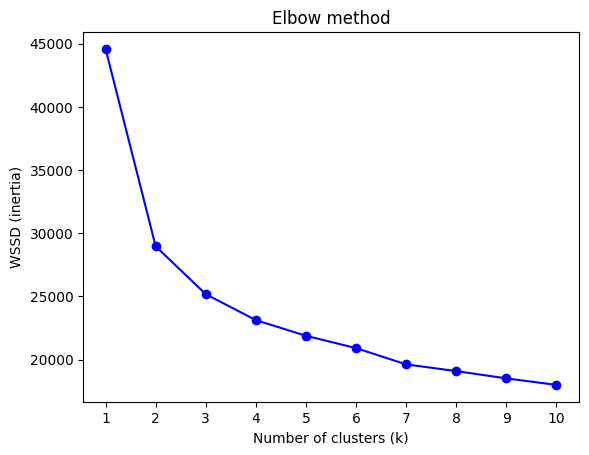

In [37]:
import matplotlib.pyplot as plt
plt.plot(clust_ks["k"], clust_ks["wssd"], "bo-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WSSD (inertia)")
plt.title("Elbow method")
plt.xticks(range(1, 11))
plt.show()

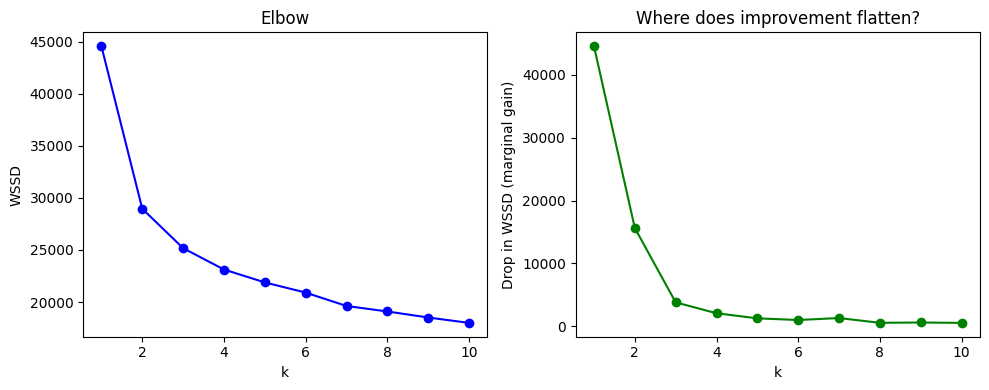

In [38]:
# Add a column for the decrease in WSSD when going from k-1 to k
clust_ks['wssd_drop'] = clust_ks['wssd'].diff().abs()
clust_ks['wssd_drop'] = clust_ks['wssd_drop'].fillna(clust_ks['wssd'].iloc[0])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(clust_ks["k"], clust_ks["wssd"], "bo-")
plt.xlabel("k")
plt.ylabel("WSSD")
plt.title("Elbow")

plt.subplot(1, 2, 2)
plt.plot(clust_ks["k"], clust_ks["wssd_drop"], "go-")
plt.xlabel("k")
plt.ylabel("Drop in WSSD (marginal gain)")
plt.title("Where does improvement flatten?")
plt.tight_layout()
plt.show()


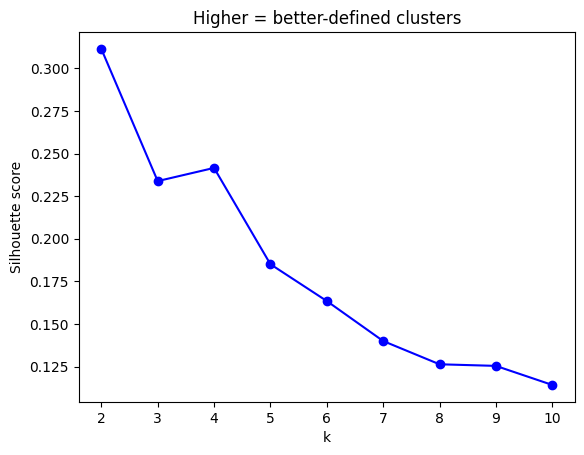

In [39]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.plot(range(2, 11), scores, "bo-")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.xticks(range(2, 11))
plt.title("Higher = better-defined clusters")
plt.show()


## 5. Fit final model & visualize

Fit KMeans with chosen k and project to 2D (PCA) for visualization.

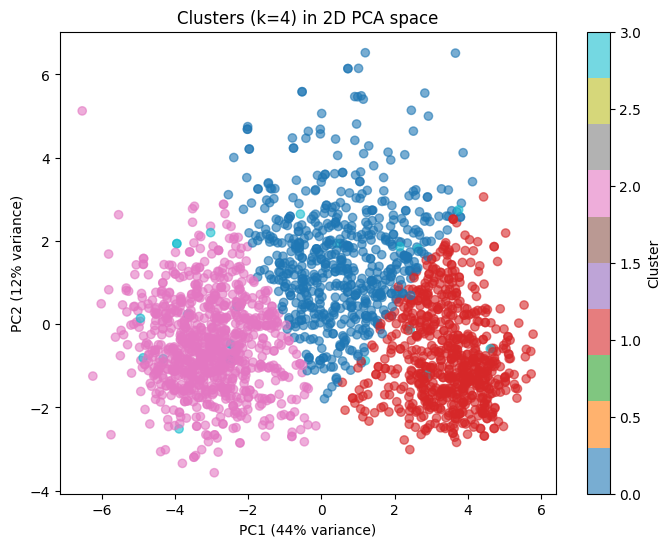

In [41]:
from sklearn.decomposition import PCA

# Reduce to 2D for plotting (run this after you've chosen k and fit the final model)
k_chosen = 4  # use whatever k you picked
kmeans = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
X_2d = np.asarray(pca.fit_transform(X))

# Scatter plot colored by cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
plt.title(f'Clusters (k={k_chosen}) in 2D PCA space')
plt.show()

## 6. Cluster profiling

Mean values of all features by cluster for persona interpretation.

In [43]:
profile = df_encoded.groupby('Cluster').agg({
    'Income': 'mean',
    'Recency': 'mean',
    'MntWines': 'mean',
    'MntFruits': 'mean',
    'MntMeatProducts': 'mean',
    'MntFishProducts': 'mean',
    'MntSweetProducts': 'mean',
    'MntGoldProds': 'mean',
    'NumDealsPurchases': 'mean',
    'NumWebPurchases': 'mean',
    'NumCatalogPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'NumWebVisitsMonth': 'mean',
    'AcceptedCmp1': 'mean',
    'AcceptedCmp2': 'mean',
    'AcceptedCmp3': 'mean',
    'AcceptedCmp4': 'mean',
    'AcceptedCmp5': 'mean',
    'Complain': 'mean',
    'Response': 'mean',
    'Age': 'mean',
    'Customer_Tenure_Days': 'mean',
    'Total_Spending': 'mean',
    'Total_Purchases': 'mean',
    'Children_at_home': 'mean',
    'Family_Size': 'mean',
    'Education_2n_Cycle': 'mean',
    'Education_Graduate': 'mean',
    'Education_Master': 'mean',
    'Education_PhD': 'mean',
    'Education_Undergraduate': 'mean',
    'Living_With_Partner': 'mean',
}).round(2)

profile.insert(0, 'Count', df_encoded.groupby('Cluster').size())
profile

KeyError: "Label(s) ['Education_2n_Cycle', 'Education_Graduate', 'Education_Master'] do not exist"

In [44]:
profile = df_encoded.groupby('Cluster').mean(numeric_only=True).round(2)
profile.insert(0, 'Count', df_encoded.groupby('Cluster').size())
profile

,Count,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,Age,Customer_Tenure_Days,Total_Spending,Total_Purchases,Children_at_home,Family_Size,Education_PhD,Education_Postgraduate,Education_Undergraduate,Living_With_Partner
Cluster,,,,,,,,,,,,,,,,,,,,,
0,611,54172.34,49.27,5.65,2.14,4.50,2.40,2.12,3.60,4.03,...,60.18,4671.94,20.42,19.43,1.27,2.93,0.26,0.19,0.07,0.67
1,700,73184.44,49.58,6.20,3.78,5.80,4.20,3.80,3.96,1.41,...,58.06,4615.88,27.75,20.83,0.30,1.92,0.21,0.15,0.09,0.62
2,898,33204.92,48.58,2.85,1.11,2.58,1.35,1.13,2.16,1.86,...,54.27,4573.33,11.19,7.14,1.24,2.89,0.20,0.16,0.16,0.65
3,20,45672.40,50.75,4.06,2.05,3.76,2.02,1.84,2.73,2.40,...,57.65,4690.70,16.45,13.60,1.20,2.85,0.05,0.10,0.15,0.65


In [45]:
profile.T

Cluster,0,1,2,3
Count,611.00,700.00,898.00,20.00
Income,54172.34,73184.44,33204.92,45672.40
Recency,49.27,49.58,48.58,50.75
MntWines,5.65,6.20,2.85,4.06
MntFruits,2.14,3.78,1.11,2.05
MntMeatProducts,4.50,5.80,2.58,3.76
MntFishProducts,2.40,4.20,1.35,2.02
MntSweetProducts,2.12,3.80,1.13,1.84
MntGoldProds,3.60,3.96,2.16,2.73
NumDealsPurchases,4.03,1.41,1.86,2.40


# Cluster 0
Highly Educated, Busy Parents
Will Shop for deals


# Cluster 1
Dual Income No kids 
High Spenders, No Discount-needed

# Cluster 2
Bottom Earners, Younger, Online / budget Shoppers

# Cluster 3
Blue collar workers

## 7. Statistical significance

Kruskal-Wallis test: which features differ significantly across clusters?

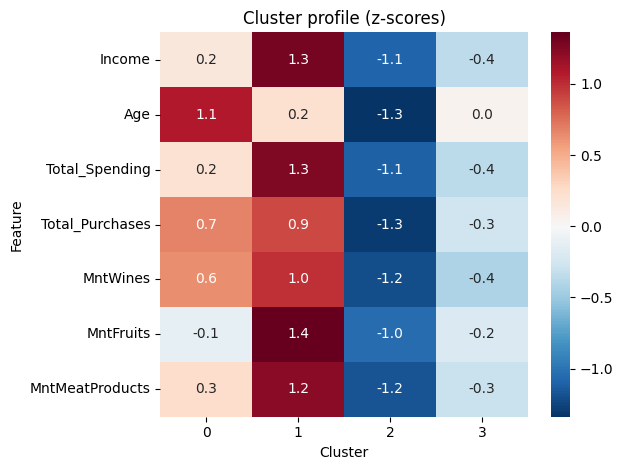

In [ ]:
# Heatmap: clusters vs key features (z-score for comparability)
key_cols = ['Family_Size', 'Income', 'Age', 'Total_Spending', 'Total_Purchases', 'MntWines', 'MntFruits', 'MntMeatProducts']
profile_norm = (profile[key_cols] - profile[key_cols].mean()) / profile[key_cols].std()
sns.heatmap(profile_norm.T, cmap='RdBu_r', center=0, annot=True, fmt='.1f')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.title('Cluster profile (z-scores)')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# For each numeric feature, run one-way ANOVA: do cluster means differ?
results = []
for col in profile.columns:
    if col == 'Count':
        continue
    groups = [df_encoded.loc[df_encoded['Cluster'] == k, col].values for k in df_encoded['Cluster'].unique()]
    # ANOVA assumes normality; use Kruskal-Wallis if data is skewed
    stat, p = stats.f_oneway(*groups)
    results.append({'feature': col, 'F_stat': stat, 'p_value': p})

sig_df = pd.DataFrame(results)
sig_df['significant'] = sig_df['p_value'] < 0.05
sig_df = sig_df.sort_values('p_value')
sig_df

,feature,F_stat,p_value,significant
0,Income,1514.400565,0.000000e+00,True
18,Complain,inf,0.000000e+00,True
22,Total_Spending,3060.348415,0.000000e+00,True
23,Total_Purchases,1773.330368,0.000000e+00,True
11,NumStorePurchases,896.247184,0.000000e+00,True
6,MntSweetProducts,741.376412,0.000000e+00,True
10,NumCatalogPurchases,1115.116610,0.000000e+00,True
4,MntMeatProducts,2569.683907,0.000000e+00,True
3,MntFruits,780.090543,0.000000e+00,True
2,MntWines,1916.640468,0.000000e+00,True


In [48]:
results = []
for col in profile.columns:
    if col == 'Count':
        continue
    groups = [df_encoded.loc[df_encoded['Cluster'] == k, col].values for k in df_encoded['Cluster'].unique()]
    stat, p = stats.kruskal(*groups)  # Kruskal-Wallis
    results.append({'feature': col, 'H_stat': stat, 'p_value': p})

sig_df = pd.DataFrame(results)
sig_df['significant'] = sig_df['p_value'] < 0.05
sig_df.sort_values('p_value')

,feature,H_stat,p_value,significant
0,Income,1548.638963,0.000000e+00,True
18,Complain,2228.000000,0.000000e+00,True
22,Total_Spending,1781.703456,0.000000e+00,True
23,Total_Purchases,1584.344145,0.000000e+00,True
11,NumStorePurchases,1470.650903,0.000000e+00,True
10,NumCatalogPurchases,1630.939901,0.000000e+00,True
4,MntMeatProducts,1750.855333,0.000000e+00,True
2,MntWines,1565.206881,0.000000e+00,True
9,NumWebPurchases,1312.359926,3.061681e-284,True
5,MntFishProducts,1223.928955,4.713861e-265,True
